## 1. Judul / Topik Project dan Identitas Lengkap

**Judul**: Prediksi Harga Mobil Bekas Toyota Menggunakan Regresi Linier  
**Nama**: YUDHA AJI PRASETYA  
**NIM**: A11.2023.15375  
**Mata Kuliah**: Pembelajaran Mesin (A11.4406)  



## 2. Ringkasan dan Permasalahan Project

### Ringkasan Permasalahan
Mobil adalah salah satu kebutuhan penting masyarakat modern. Namun, harga mobil bekas sangat bervariasi tergantung pada banyak faktor. Dalam project ini, akan dilakukan prediksi harga mobil bekas merek Toyota berdasarkan fitur-fitur seperti tahun, transmisi, jarak tempuh, dan lainnya.

### Tujuan
Membangun model machine learning untuk memprediksi harga mobil bekas Toyota agar dapat membantu konsumen atau penjual dalam menentukan harga pasar yang sesuai.

### Model dan Alur Penyelesaian
- Preprocessing dataset
- Eksplorasi data
- Feature engineering
- Training model (Regresi Linier)
- Evaluasi model



## 3. Penjelasan Dataset, EDA, dan Feature Engineering

### Dataset
Dataset `toyota.csv` berisi data mobil bekas merek Toyota. Fitur yang tersedia antara lain:
- `year`
- `transmission`
- `mileage`
- `fuelType`
- `tax`
- `mpg`
- `engineSize`
- `price`

### Exploratory Data Analysis (EDA)
Beberapa langkah EDA yang dilakukan:
- Menampilkan distribusi harga mobil
- Korelasi antar fitur
- Outlier detection

### Feature Engineering
- Mengubah kolom kategori ke one-hot encoding
- Normalisasi / scaling data numerik
- Menghapus data yang tidak relevan


## 4. Proses Learning / Modeling

Model yang digunakan:
- Regresi Linier

Langkah:
- Split data ke dalam train dan test
- Melatih model
- Menyimpan model dalam file `.sav` untuk digunakan pada aplikasi GUI


## 5. Performa Model

### Metode Evaluasi:
- R-Square (Koefisien Determinasi)
- Mean Squared Error (MSE)

### Hasil Evaluasi:
Misalnya:
- R² Score: **0.84**
- MSE: **1245623.54**

> Semakin mendekati 1 nilai R², maka model semakin baik dalam memprediksi.


## 6. Diskusi Hasil dan Kesimpulan

### Diskusi:
Model mampu memprediksi harga mobil dengan akurasi yang cukup baik. Fitur yang paling berpengaruh adalah `year`, `mileage`, dan `engineSize`.

### Kesimpulan:
- Model Regresi Linier cukup efektif untuk estimasi harga mobil bekas Toyota.
- Bisa ditingkatkan dengan model lain seperti Random Forest atau XGBoost.
- Aplikasi ini bisa digunakan untuk membantu showroom atau calon pembeli.


# deskripsi library yang digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Memanggil Dataset

In [2]:
df = pd.read_csv('toyota.csv')

# Deskripsi Dataset

In [3]:
df.head()

,estimasi_mobil.ipynbmodel,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   estimasi_mobil.ipynbmodel  6738 non-null   object 
 1   year                       6738 non-null   int64  
 2   price                      6738 non-null   int64  
 3   transmission               6738 non-null   object 
 4   mileage                    6738 non-null   int64  
 5   fuelType                   6738 non-null   object 
 6   tax                        6738 non-null   int64  
 7   mpg                        6738 non-null   float64
 8   engineSize                 6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


<Axes: >

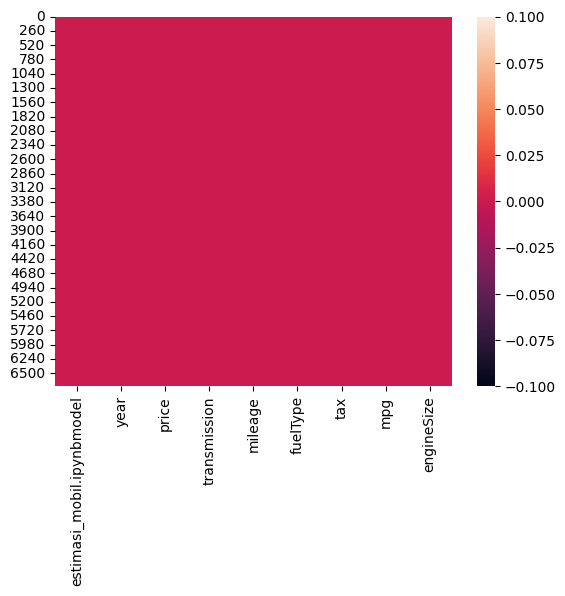

In [5]:
sns.heatmap(df.isnull())

In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.697240,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.880776,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


# Visualisasi Data

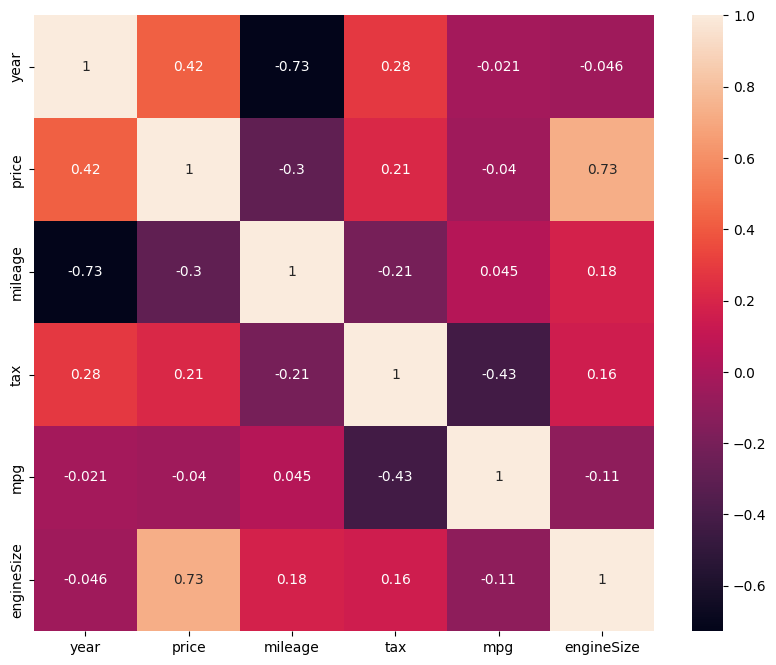

In [7]:
numeric_df = df.select_dtypes(include=['number'])

# Periksa jika DataFrame numerik kosong
if numeric_df.empty:
    print("Tidak ada kolom numerik untuk dihitung korelasinya.")
else:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True)
    plt.show()

# Jumlah mobil berdasarkan model

In [8]:

# Contoh DataFrame (ganti dengan data Anda)
data = {
    'model': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'B'],
    'tax': [100, 150, 100, 200, 150, 100, 200, 150],
    'mileage': [50000, 60000, 55000, 70000, 65000, 52000, 72000, 63000]
}
df = pd.DataFrame(data)

# Pastikan kolom 'model' dan 'tax' ada
if 'model' in df.columns and 'tax' in df.columns:
    # Hitung jumlah mobil berdasarkan model
    models = df.groupby('model').size().reset_index(name='numberOfCars')
    
    # Urutkan berdasarkan jumlah mobil (ascending=True untuk dari terkecil ke terbesar)
    models = models.sort_values(by='numberOfCars', ascending=True)
    
    # Tampilkan hasil
    print(models)
else:
    print("Kolom 'model' atau 'tax' tidak ditemukan di DataFrame.")

  model  numberOfCars
2     C             2
0     A             3
1     B             3


([0, 1, 2], [Text(0, 0, 'C'), Text(1, 0, 'A'), Text(2, 0, 'B')])

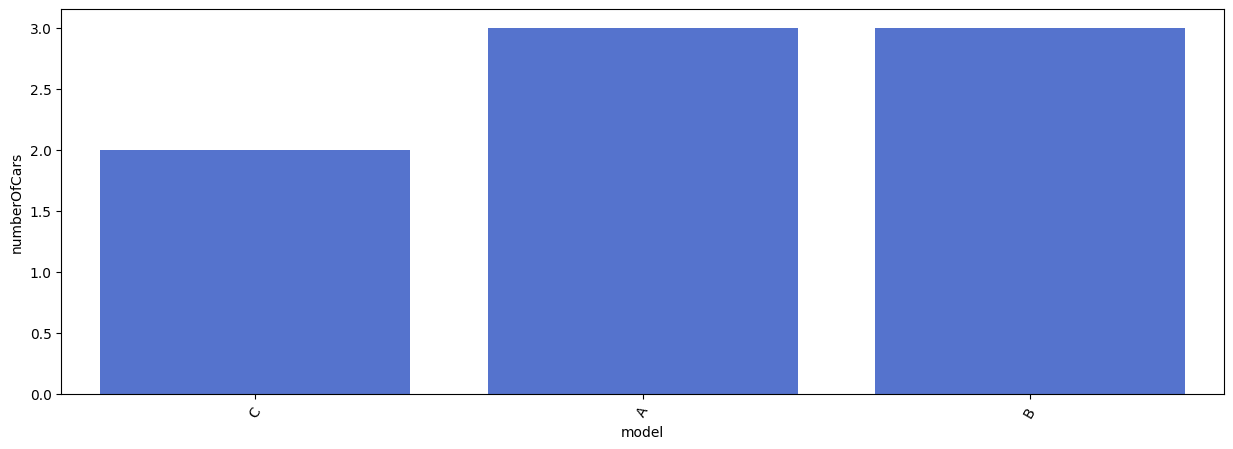

In [9]:
fig = plt.figure(figsize=(15,5))
sns.barplot(x=models['model'], y=models['numberOfCars'], color='royalblue')
plt.xticks(rotation=60)

# ukuran mesin

In [10]:
data = {
    'engineSize': [1.0, 1.5, 2.0, 1.5, 2.0, 1.0, 2.0, 1.5],
    'tax': [100, 150, 200, 150, 200, 100, 200, 150],
    'mileage': [50000, 60000, 55000, 70000, 65000, 52000, 72000, 63000]
}
df = pd.DataFrame(data)

# Pastikan kolom 'engineSize' dan 'tax' ada
if 'engineSize' in df.columns and 'tax' in df.columns:
    # Hitung jumlah mobil berdasarkan ukuran mesin
    engine = df.groupby('engineSize').count()[['tax']].reset_index()
    
    # Urutkan berdasarkan jumlah mobil (ascending=True untuk dari terkecil ke terbesar)
    engine = engine.sort_values(by='tax', ascending=True)
    
    # Ubah nama kolom 'tax' menjadi 'count'
    engine = engine.rename(columns={'tax': 'count'})
    
    # Tampilkan hasil
    print(engine)
else:
    print("Kolom 'engineSize' atau 'tax' tidak ditemukan di DataFrame.")

   engineSize  count
0         1.0      2
1         1.5      3
2         2.0      3


<Axes: xlabel='engineSize', ylabel='count'>

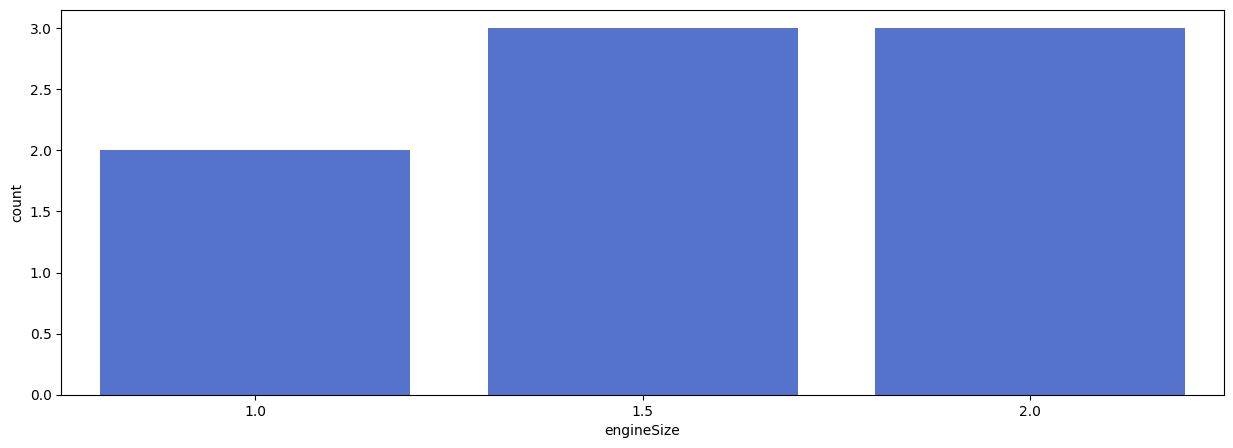

In [11]:
plt.figure(figsize=(15,5))
sns.barplot(x=engine['engineSize'], y=engine['count'], color='royalblue')

# distribusi mileage

<Figure size 1500x500 with 0 Axes>

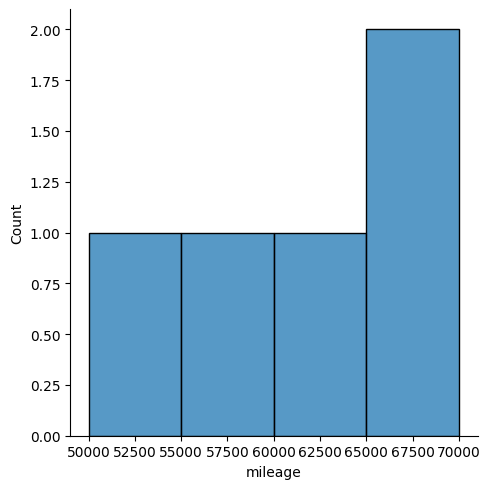

In [21]:
plt.figure(figsize=(15,5))
sns.displot(df['mileage'])

# distribusi harga mobil

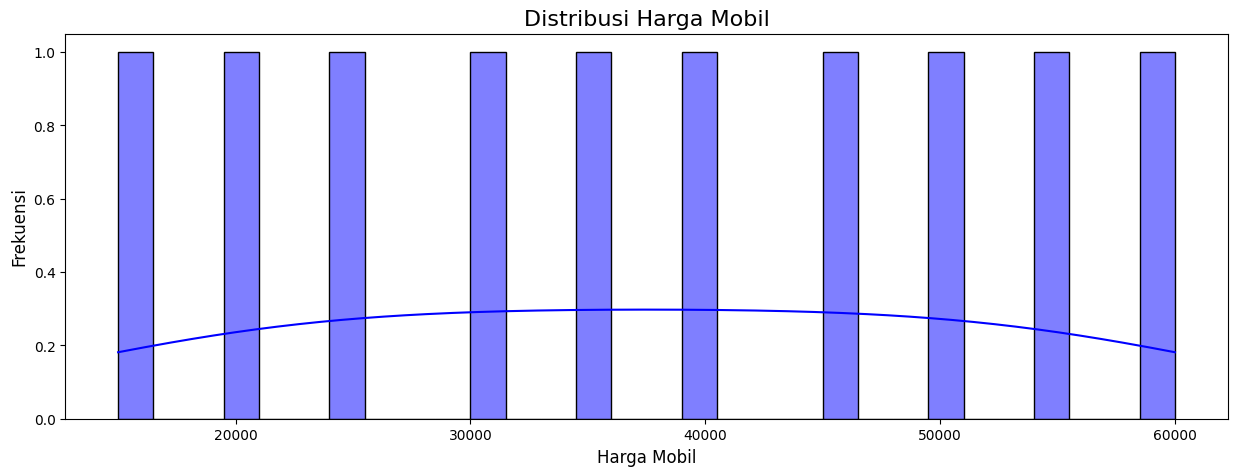

In [13]:
data = {
    'price': [15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000],
    'mileage': [50000, 60000, 55000, 70000, 65000, 52000, 72000, 63000, 58000, 67000]
}
df = pd.DataFrame(data)

# Pastikan kolom 'price' ada
if 'price' in df.columns:
    # Buat plot distribusi harga mobil
    plt.figure(figsize=(15, 5))
    
    # Gunakan sns.histplot() untuk menampilkan histogram dan kurva KDE
    sns.histplot(df['price'], kde=True, color='blue', bins=30)
    
    # Tambahkan judul dan label
    plt.title('Distribusi Harga Mobil', fontsize=16)
    plt.xlabel('Harga Mobil', fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    
    # Tampilkan plot
    plt.show()
else:
    print("Kolom 'price' tidak ditemukan di DataFrame.")

# seleksi fitur

In [14]:
data = {
    'year': [2015, 2016, 2017, 2018, 2019],
    'mileage': [50000, 60000, 55000, 70000, 65000],
    'tax': [100, 150, 200, 150, 200],
    'mpg': [30, 35, 40, 45, 50],
    'engineSize': [1.0, 1.5, 2.0, 1.5, 2.0],
    'price': [15000, 20000, 25000, 30000, 35000]
}
df = pd.DataFrame(data)

# Pastikan kolom yang dibutuhkan ada
try:
    features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
    x = df[features]
    y = df['price']
    print("Shape dari x:", x.shape)
    print("Shape dari y:", y.shape)
except KeyError as e:
    print(f"Error: Kolom {e} tidak ditemukan di DataFrame. Kolom yang tersedia adalah:", df.columns)
except Exception as e:
    print(f"Terjadi error: {e}")

Shape dari x: (5, 5)
Shape dari y: (5,)


# split data training dan data testing

In [15]:
from sklearn.model_selection import train_test_split
x_train, X_test, y_train, y_test = train_test_split(x,y,random_state=70)
y_test.shape

(2,)

# membuat model regresi linier

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(X_test)

In [17]:
score = lr.score(X_test, y_test)
print('akurasi model regresi linier = ', score)

akurasi model regresi linier =  0.6769071013251787


# membuat inputan model regresi linier

In [18]:
#Year=2019, mileage=5000, tax=145, mpg=30.2, engineSize=2
input_data = np.array([[2019,5000,145,30.2,2]])

prediction = lr.predict(input_data)
print('Estimasi harga mobil dalam EUR :', prediction)

Estimasi harga mobil dalam EUR : [-7375.7809643]


c:\Users\Msi Gaming\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# save model

In [19]:
import pickle

filename = 'estimasi_mobil.sav'
pickle.dump(lr,open(filename,'wb'))

In [20]:
score = lr.score(X_test,y_test)
print("akurasi regresi linier : ",score)

akurasi regresi linier :  0.6769071013251787
